# ДЗ №1: Визуализация механизмов Attention в трансформерах

## 🎯 Цель задания
После выполнения задания вы сможете:
- Визуализировать работу self-attention механизма
- Сравнивать различные реализации QKV в BERT, GPT и T5
- Анализировать позиционные векторы и их влияние на понимание последовательности
- Интерпретировать attention-карты для объяснения решений модели

## 📝 Структура задания
- **Часть 1** (обязательная, 70% оценки): Базовая визуализация attention
- **Часть 2** (дополнительная, 30% оценки): Продвинутый анализ

## ⚡ Критерии оценки
- Корректность кода: 40%
- Качество визуализации: 30%
- Анализ результатов: 30%


## 🔧 Установка зависимостей

Установим необходимые библиотеки для работы с трансформерами и визуализации.


In [1]:
%pip install transformers torch matplotlib seaborn bertviz numpy pandas
%pip install -q ipywidgets

  Using cached transformers-5.0.0-py3-none-any.whl.metadata (37 kB)
  Using cached torch-2.10.0-cp313-none-macosx_11_0_arm64.whl.metadata (31 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached bertviz-1.4.1-py3-none-any.whl.metadata (19 kB)
  Using cached numpy-2.4.2-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached filelock-3.20.3-py3-none-any.whl.metadata (2.1 kB)
  Using cached huggingface_hub-1.3.7-py3-none-any.whl.metadata (13 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached regex-2026.1.15-cp313-cp313-macosx_11_0_arm64.whl.metadata (40 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-macosx_11_0_arm64.whl.metadata (7.3 kB)
  Using cached typer_slim-0.21.1-py3-none-any.whl.metadata (16 kB)
  Using cached safetensors-0.7.0-cp

In [ ]:
# Импорт необходимых библиотек
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    AutoTokenizer, AutoModel,
    BertTokenizer, BertModel,
    GPT2Tokenizer, GPT2Model,
    T5Tokenizer, T5Model
)
from bertviz import model_view, head_view
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline


Matplotlib is building the font cache; this may take a moment.


## 📊 Часть 1: Основные задания (обязательная часть)

### Задание 1.1: Загрузка и подготовка моделей


In [ ]:

# Загружаем модели для сравнения
models_info = {
    'BERT': {
        'model_name': 'bert-base-uncased',
        'tokenizer': None,
        'model': None
    },
    'GPT-2': {
        'model_name': 'gpt2',
        'tokenizer': None,
        'model': None
    }
}

# TODO: Загрузите токенизаторы и модели для BERT и GPT-2
# используя библиотеку Transformers
#
# Заполните словарь models_info

models_info['BERT']['tokenizer'] = BertTokenizer.from_pretrained("google-bert/bert-base-uncased")
models_info['BERT']['model'] = BertModel.from_pretrained("google-bert/bert-base-uncased", attn_implementation="eager")
models_info['GPT-2']['tokenizer'] = GPT2Tokenizer.from_pretrained("openai-community/gpt2")
models_info['GPT-2']['model'] = GPT2Model.from_pretrained("openai-community/gpt2", attn_implementation="eager")

print("Модели загружены успешно!")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: openai-community/gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Модели загружены успешно!


### Задание 1.2: Токенизация и получение attention весов

In [8]:
# Тестовый текст для анализа
test_text = "The cat sat on the mat and looked at the dog."
print(f"Анализируемый текст: {test_text}")

def get_attention_weights(text, model_name):
    """
    Получение attention весов для заданного текста и модели
    """
    tokenizer = models_info[model_name]['tokenizer']
    model = models_info[model_name]['model']

    inputs = tokenizer(
        text,
        return_tensors="pt",
        return_attention_mask=True,
    )

    outputs = model(**inputs, output_attentions=True, return_dict=True)

    attentions = outputs.attentions
    attention_weights = torch.stack(attentions, dim=0).squeeze(1).detach().cpu()

    token_ids = inputs["input_ids"][0].detach().cpu().tolist()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    return attention_weights, tokens, inputs

# Получаем attention веса для обеих моделей
bert_attention, bert_tokens, bert_inputs = get_attention_weights(test_text, 'BERT')
gpt2_attention, gpt2_tokens, gpt2_inputs = get_attention_weights(test_text, 'GPT-2')

print(f"BERT tokens: {bert_tokens}")
print(f"GPT-2 tokens: {gpt2_tokens}")
print(f"BERT attention shape: {bert_attention[0].shape}")
print(f"GPT-2 attention shape: {gpt2_attention[0].shape}")


Анализируемый текст: The cat sat on the mat and looked at the dog.
BERT tokens: ['[CLS]', 'the', 'cat', 'sat', 'on', 'the', 'mat', 'and', 'looked', 'at', 'the', 'dog', '.', '[SEP]']
GPT-2 tokens: ['The', 'Ġcat', 'Ġsat', 'Ġon', 'Ġthe', 'Ġmat', 'Ġand', 'Ġlooked', 'Ġat', 'Ġthe', 'Ġdog', '.']
BERT attention shape: torch.Size([12, 14, 14])
GPT-2 attention shape: torch.Size([12, 12, 12])


### Задание 1.3: Создание базовой attention heatmap

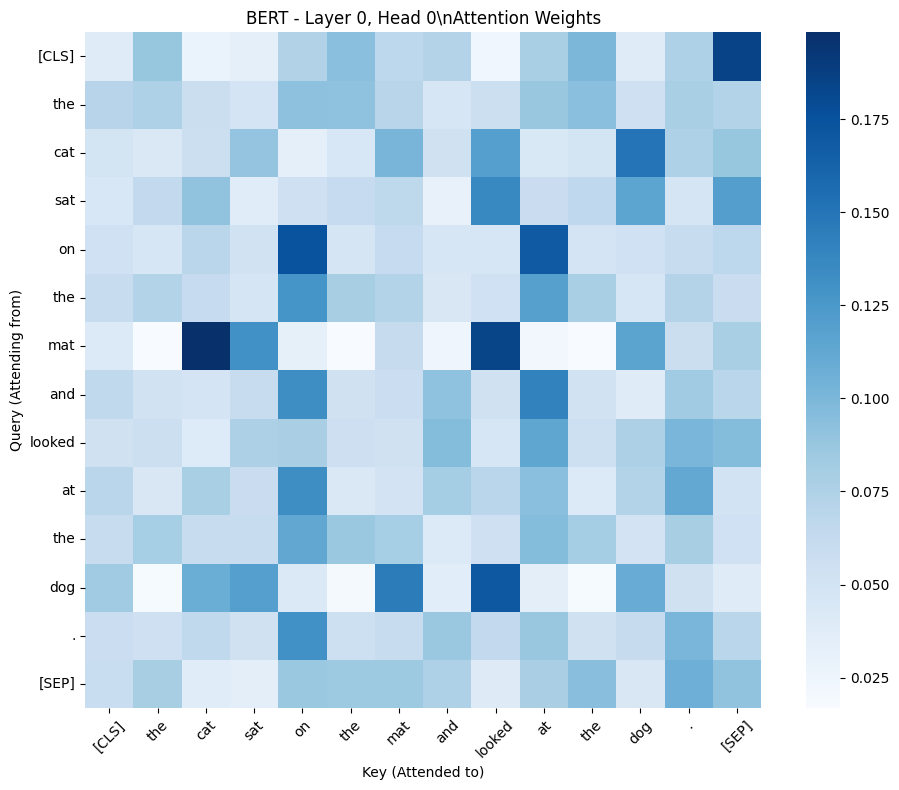

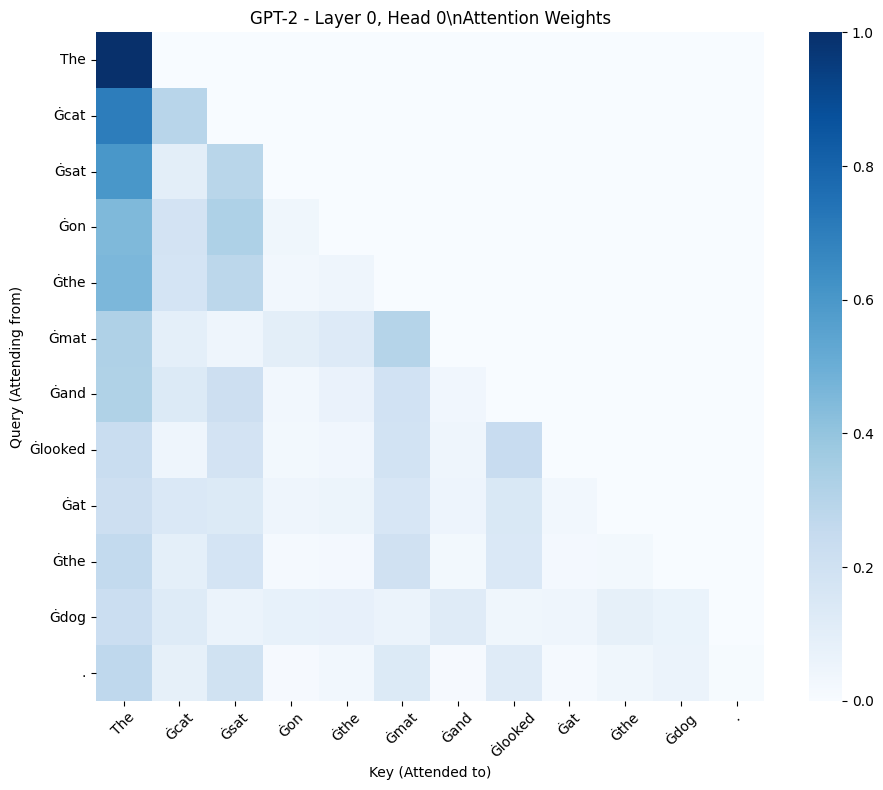

In [9]:
def plot_attention_heatmap(attention_weights, tokens, model_name, layer_idx=0, head_idx=0):
    """
    Создание heatmap для визуализации attention весов
    """
    # TODO: Извлеките attention веса для указанного слоя и головы
    attention_matrix = attention_weights[layer_idx, head_idx]
    attention_matrix = attention_matrix.detach().cpu().numpy()

    # ToDo: Создаем heatmap


    # TODO: Созданиее heatmap используя seaborn ( можно использовать другие библиотеки)
    # основная задача - визуализировать веса на каждый токен ( слово )
    plt.figure(figsize=(10, 8))
    sns.heatmap(
       attention_matrix,
       xticklabels=tokens,
       yticklabels=tokens,
       cmap='Blues',
       cbar=True,
       square=True
    )

    plt.title(f'{model_name} - Layer {layer_idx}, Head {head_idx}\\nAttention Weights')
    plt.xlabel('Key (Attended to)')
    plt.ylabel('Query (Attending from)')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Визуализируем attention для первого слоя и первой головы
plot_attention_heatmap(bert_attention, bert_tokens, 'BERT', layer_idx=0, head_idx=0)
plot_attention_heatmap(gpt2_attention, gpt2_tokens, 'GPT-2', layer_idx=0, head_idx=0)


### Задание 1.4: Анализ результатов

**TODO: Ответьте на следующие вопросы:**


1. **Какие различия вы заметили в attention patterns между BERT и GPT-2?**

   - направленность внимания - у BERT внимание распределено по всем токенам, у GPT - только на себя и прошлые токены
   - у BERT есть спецтокены, которые тоже участвуют во внимании
   - у GPT последний слой выглядит "рабочим" - внимание распределено не только по ближайшим токенам и несколько похож на нулевой. У BERT'а в последнем слое все внимание на последний токен и на финальный спецтокен
  

2. **Как изменяются attention веса в разных слоях?**

   - у BERT'a в начальных слоях (кроме 0 и 1) внимание токенов сосредотачивается сначала на себя (выраженная диагональ), потом на себя и служебные токены, затем в средних слоях начинают играть важную роль соседние токены, после этого появляются дальние связи (они также есть и в слоях 0, 1) и в верхних слоях внимание уходит на спецтокены
   - у GPT часть слоев смотрит в основном на первый/ые токены, часть слоев с большим вниманием ближайших предыдущих токенов и несколько слоев где внимание размазывается по дальним токенам в том числе (0 и 11 слой, но в нулевом внимание больше на первом токене). И все они чередуются - какой-то закономерности не вижу, разве что похоже, что последний слой GPT используется для декодера и поэтому выглядит "прилично"

3. **Какую роль играют позиционные кодировки?**

   - "понимание" для модели о порядке токенов и о том насколько далеко друг от друга они расположены (что может влиять на силу связи между ними)
   - дает возможность различать одинаковые по содержанию токены (например the)
   - видно что в некторых слоях четко прослеживается внимание на ближайшие предыдущие токены


## 🚀 Часть 2: Дополнительные задания (30% оценки)

### Задание 2.1: Исследование Multi-Head Attention


In [ ]:
def analyze_multi_head_attention(attention_weights, tokens, model_name, layer_idx=6):
    """
    Анализ того, как разные головы attention фокусируются на разных аспектах
    """
    num_heads = ...

    # TODO: Создайте визуализацию attention для всех голов в одном слое


# Анализируем multi-head attention для средних слоев
analyze_multi_head_attention(bert_attention, bert_tokens, 'BERT', layer_idx=6)


### Задание 2.2: Создание attention-карт для русскоязычного текста


In [ ]:
# TODO: Загрузите русскоязычную модель и проанализируйте attention для русского текста
# ========= РЕШЕНИЕ: =========
from transformers import AutoTokenizer, AutoModel

# Загружаем русскоязычную модель
# Напрмимер можно использовать DeepPavlov/rubert-base-cased
ru_tokenizer = ...
ru_model = ...

# Русский текст для анализа
russian_text = "Кот сидел на ковре и смотрел на собаку."

def analyze_russian_attention(text, tokenizer, model):
    """
    Анализ attention для русского текста
    """
    # Токенизация
    inputs = ...
    outputs = ...
    attention_weights = ...
    tokens = ...

    # Создаем heatmap для последнего слоя
    attention_matrix = ...

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        attention_matrix,
        xticklabels=tokens,
        yticklabels=tokens,
        cmap='Blues',
        cbar=True,
        square=True,
        annot=True,
        fmt='.2f'
    )

    plt.title(f'RuBERT Attention Heatmap\\nText: {text}')
    plt.xlabel('Key (Attended to)')
    plt.ylabel('Query (Attending from)')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return attention_weights, tokens

# Анализируем русский текст
ru_attention, ru_tokens = analyze_russian_attention(russian_text, ru_tokenizer, ru_model)

print(f"\\nТокены: {ru_tokens}")
print(f"Количество слоев: {len(ru_attention)}")
print(f"Количество голов: {ru_attention[0].shape[1]}")


## 📈 Итоговый анализ и выводы

### Задание 3: Сравнительный анализ

**TODO: Сделайте итоговые выводы по результатам всех экспериментов:**


1. **Основные различия между BERT и GPT-2:**

   *Ваш анализ:*

2. **Как attention головы специализируются:**

   *Ваш анализ:*

3. **Особенности русскоязычных моделей:**

   *Ваш анализ:*

4. **Практические применения полученных знаний:**

   *Ваш анализ:*


## 🎯 Заключение

В этом задании вы:
- ✅ Изучили механизмы attention в трансформерах
- ✅ Сравнили разные архитектуры (BERT vs GPT-2)
- ✅ Проанализировали специализацию attention голов
- ✅ Работали с русскоязычными моделями

Полученные навыки визуализации и анализа attention будут полезны для:
- Отладки и оптимизации моделей
- Объяснения решений AI-систем
- Выбора подходящей архитектуры для задач
- Интерпретации поведения моделей

## 📋 Критерии сдачи ДЗ

### Обязательная часть (70% оценки):
- [x] Загружены и настроены модели BERT и GPT-2
- [x] Реализована функция получения attention весов
- [x] Создана базовая визуализация attention heatmap
- [x] Даны ответы на аналитические вопросы

### Дополнительная часть (30% оценки):
- [x] Проанализированы multi-head attention паттерны
- [x] Работа с русскоязычной моделью
- [x] Итоговый сравнительный анализ

**Удачи в дальнейшем изучении трансформеров! 🚀**
